# Lab 12 — Motion-Model Bayes Localization

Step through a simulated drive while a 2D Bayes filter (gyro-conditioned) tracks the robot.

**Pipeline per BLE round-trip:**

1. Controller picks `(speed_pwm, target_heading)` for the current waypoint.
2. `SimRobot.update(...)` advances physics by one BLE rtt and returns the latest cached ToF samples (each tagged with the yaw at sample time).
3. `Localization2D.predict(...)` shifts the belief by the commanded displacement and diffuses it anisotropically along the heading.
4. `Localization2D.update(...)` indexes into the per-cell ray cache at each ToF's bearing and multiplies the likelihood into the belief.

## 1. Setup

In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # so 'from world import ...' resolves

import time, math
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from world import load_world
from sim_robot import SimRobot
from localization2d import Localization2D
from controller import SplineController, BeliefPlot, step_once
from paths import LAB_PATH_M


In [2]:
# Frame recorder: copies the canvas RGBA on the main thread (fast),
# then encodes PNG in a background pool so the loop is not blocked.
import io, time, shutil, subprocess, threading
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import numpy as np
from PIL import Image


class FrameRecorder:
    def __init__(self, out_dir, max_workers=4, compress_level=1):
        self.out = Path(out_dir)
        if self.out.exists():
            shutil.rmtree(self.out)
        self.out.mkdir(parents=True, exist_ok=True)
        self._exe = ThreadPoolExecutor(max_workers=max_workers)
        self._compress = compress_level
        self.n = 0
        self.t0 = None
        self.t_last = None

    @staticmethod
    def _encode(path, rgba, compress):
        Image.fromarray(rgba).save(path, format="PNG", compress_level=compress)

    def capture(self, fig):
        # Force a draw, then copy the RGBA buffer (cheap memcpy).
        fig.canvas.draw()
        w, h = fig.canvas.get_width_height()
        rgba = np.asarray(fig.canvas.buffer_rgba()).copy()
        path = self.out / f"frame_{self.n:05d}.png"
        self.n += 1
        now = time.time()
        if self.t0 is None:
            self.t0 = now
        self.t_last = now
        self._exe.submit(self._encode, str(path), rgba, self._compress)

    def fps(self):
        if self.n < 2 or self.t0 is None or self.t_last is None:
            return 30.0
        dt = max(1e-3, self.t_last - self.t0)
        return (self.n - 1) / dt

    def close(self):
        self._exe.shutdown(wait=True)

    def make_video(self, output_path, fps=None):
        self.close()
        if self.n == 0:
            print("no frames recorded")
            return None
        fps = fps if fps is not None else self.fps()
        output_path = str(output_path)
        cmd = [
            "ffmpeg", "-y",
            "-framerate", f"{fps:.3f}",
            "-i", str(self.out / "frame_%05d.png"),
            "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2",
            "-c:v", "libx264", "-pix_fmt", "yuv420p",
            "-preset", "veryfast",
            output_path,
        ]
        print(f"stitching {self.n} frames @ {fps:.2f} fps -> {output_path}")
        subprocess.run(cmd, check=True)
        return output_path


In [3]:
PATH = LAB_PATH_M
START_THETA_DEG = 45.0
print('waypoints (m):')
for i, p in enumerate(PATH):
    print(f'  {i}: ({p[0]:+.3f}, {p[1]:+.3f})')


waypoints (m):
  0: (-1.219, -0.914)
  1: (-0.610, -0.305)
  2: (+0.305, -0.305)
  3: (+0.610, -0.914)
  4: (+1.524, -0.914)
  5: (+1.524, -0.610)
  6: (+1.676, -0.152)
  7: (+1.524, +0.914)
  8: (+0.000, +0.914)
  9: (+0.000, +0.000)


## 2. Build the world, sim, localization, controller

In [4]:
map_lines, bounds, loc_params, sim_params, ctl_kwargs = load_world()
print(f'{len(map_lines)} wall segments, bounds={bounds}')
print(f'loc params: {loc_params}')

sim = SimRobot(
    map_lines, sim_params,
    x0=PATH[0][0], y0=PATH[0][1], theta_deg=START_THETA_DEG,
)

t0 = time.time()
loc = Localization2D(map_lines, bounds, params=loc_params)
loc.init_at(PATH[0][0], PATH[0][1], sigma_m=0.10)
print(f'grid={loc.bel.shape}  cell={loc.dx*1000:.1f}x{loc.dy*1000:.1f}mm  '
      f'cache={loc.cache.mean_mm.shape}  build={time.time()-t0:.2f}s')

ctl = SplineController(path=PATH, loc=loc, map_lines=map_lines, **ctl_kwargs)


13 wall segments, bounds=(-1.6764, 1.9812, -1.3716, 1.3716)
loc params: LocParams(n_cells_x=192, n_cells_y=144, n_angles=720, smooth_sigma_deg=12.0, max_dist_m=6.0, sensor_sigma_mm=32.0, tof_sat_mm=3500.0, robust_z_max=6.0, motion_long_sigma_per_m=0.192, motion_long_sigma_per_pwm=0.016, motion_base_sigma_m=0.032, pwm_to_vel_mm_s=9.0, tof_sensor_angles_deg=(0.0, -90.0), flip_std_ratio=0.0)
grid=(192, 144)  cell=19.1x19.0mm  cache=(192, 144, 720)  build=2.15s


## 3. Initial state

The belief starts as a tight Gaussian at the known start pose.

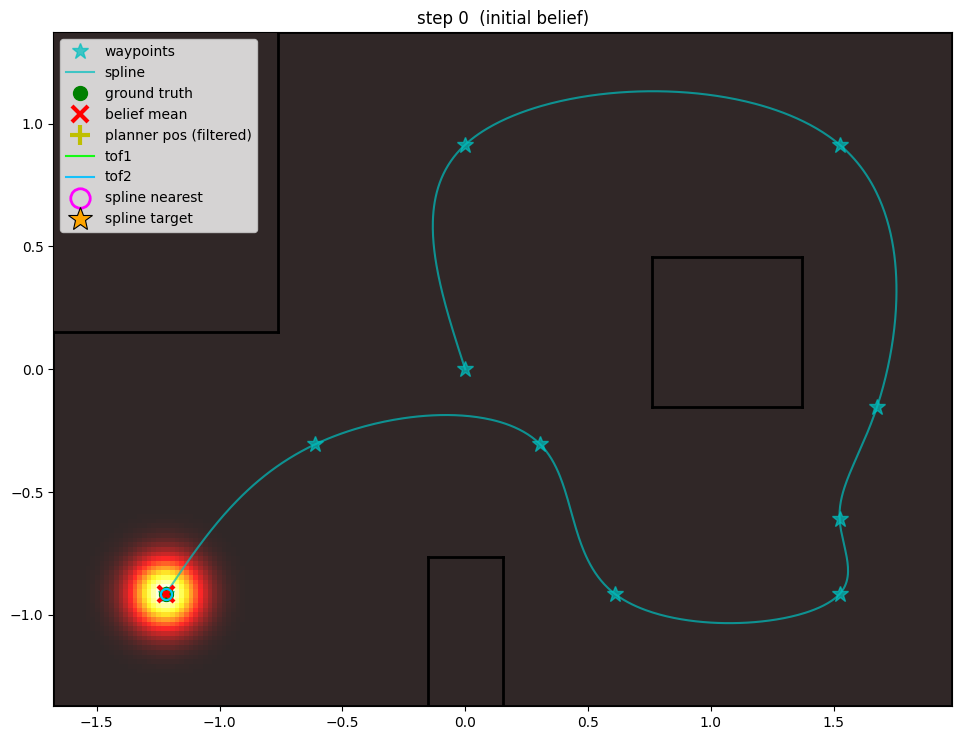

In [5]:
_, _spline_xy = ctl.spline.dense_sample(0.01)
plot = BeliefPlot(loc, map_lines, path=PATH, spline_xy=_spline_xy)
gx, gy, _ = sim.pose
# Synthetic empty response just to draw the initial state.
from sim_robot import DriveUpdateResponse
empty = DriveUpdateResponse(0, 0, 0, 0.0, 0, 0, 0.0, 0.0, 0.0, 0.0, 0.0)
plot.update((gx, gy), empty, title='step 0  (initial belief)')
plt.show()


## 4. Step once at a time

Re-run this cell to advance the simulation one BLE round-trip and refresh the plot. Watch the belief shift along the commanded heading and tighten as the side-facing ToF nails the lateral coordinate.

step 1  t=0.10s  s=0.00/8.01m  gt=(-1.212,-0.907)  bel=(-1.196,-0.909)  err=16mm  tof1=3074mm@+48.1deg  tof2=650mm@-41.9deg


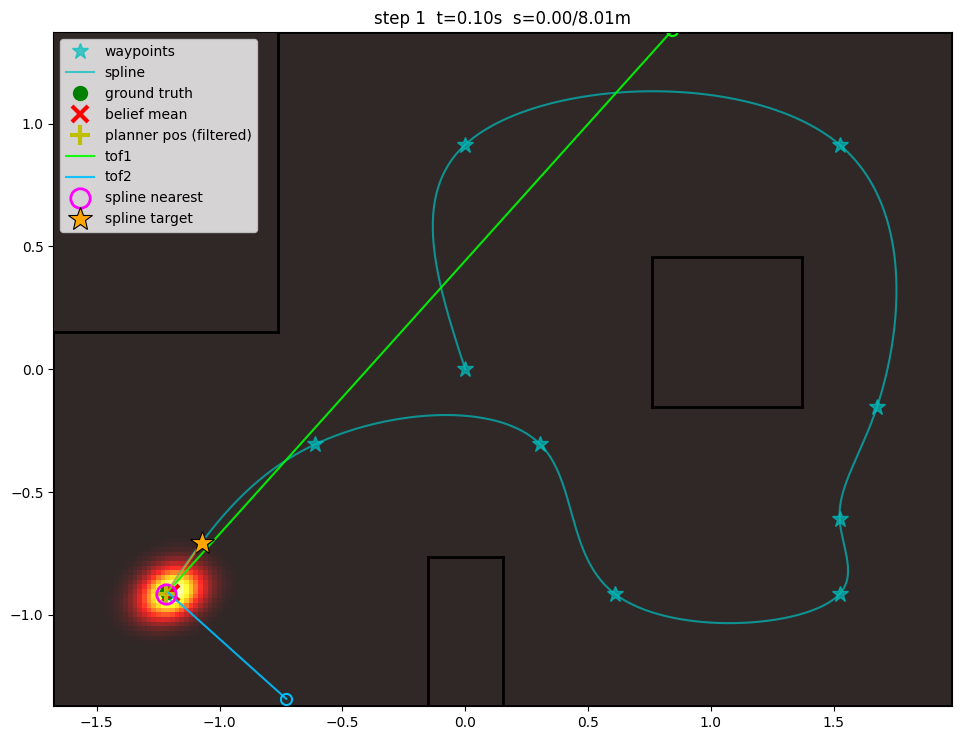

In [6]:
if 'last_t_us' not in dir():
    last_t_us = 0
if 'step' not in dir():
    step = 0
if 'last_yaw' not in dir():
    last_yaw = START_THETA_DEG

resp, last_t_us = await step_once(sim, loc, ctl, last_t_us=last_t_us, last_yaw_deg=last_yaw)
last_yaw = resp.yaw_deg
step += 1

gx, gy, gth = sim.pose
bx, by = loc.mean_xy()
err_mm = math.hypot(bx - gx, by - gy) * 1000
print(
    f'step {step}  t={sim.t_s:.2f}s  s={ctl.s_prog:.2f}/{ctl.spline.S:.2f}m  '
    f'gt=({gx:+.3f},{gy:+.3f})  bel=({bx:+.3f},{by:+.3f})  err={err_mm:.0f}mm  '
    f'tof1={resp.tof1_dist_mm}mm@{resp.tof1_yaw_deg:+.1f}deg  '
    f'tof2={resp.tof2_dist_mm}mm@{resp.tof2_yaw_deg:+.1f}deg'
)
plot.update((gx, gy), resp,
            title=f'step {step}  t={sim.t_s:.2f}s  s={ctl.s_prog:.2f}/{ctl.spline.S:.2f}m',
            filtered_xy=(ctl.filt_x, ctl.filt_y) if ctl.filt_x is not None else None,
            nearest_xy=ctl.nearest_on_spline(*((ctl.filt_x, ctl.filt_y) if ctl.filt_x is not None else loc.mean_xy()))[1:],
            target_xy=ctl.target_xy())
display(plot.fig)


## 5. Run to completion (live redraw)

Plays through the rest of the path, re-rendering every step. Stop with `Kernel → Interrupt`.

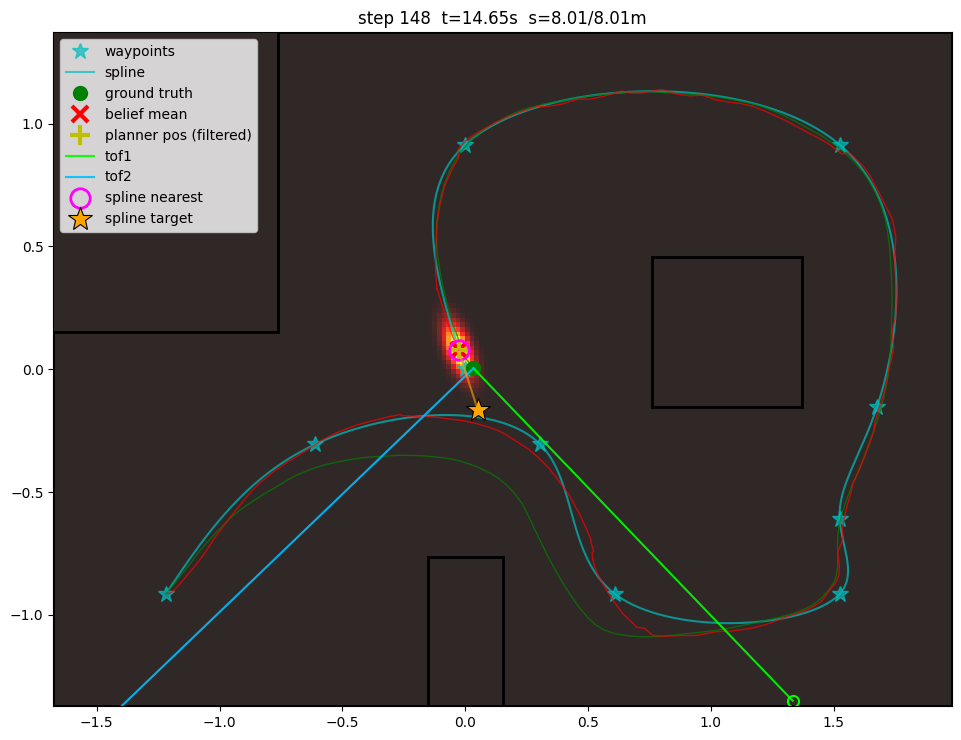

done in 148 steps. final gt=(+0.034,+0.004)  bel=(-0.026,+0.080)  err=96mm
stitching 147 frames @ 11.38 fps -> sim_open.mp4


ffmpeg version 8.1 Copyright (c) 2000-2026 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.6.4.2)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
  libavutil      60. 26.100 / 60. 26.100
  libavcodec     62. 28.100 / 62. 28.100
  libavformat    62. 12.100 / 62. 12.100
  libavdevice    62.  3.100 / 62.  3.100
  libavfilter    11. 14.100 / 11. 14.100
  libswscale      9.  5.100 /  9.  5.100
  libswresample   6.  3.100 /  6.  3.100
Input #0, image2, from 'frames_sim_open/frame_%05d.png':
  Duration: 00:00:12.91, start: 0.000000, bitrate: N/A
  Stream #0:0: Video: png, rgba(pc, gbr/unknown/unknown), 1000x750, 11.38 fps, 11.38 tbr, 11.38 t

'sim_open.mp4'

In [7]:
last_yaw = resp.yaw_deg
rec = FrameRecorder('frames_sim_open')
while not ctl.done:
    resp, last_t_us = await step_once(sim, loc, ctl, last_t_us=last_t_us, last_yaw_deg=last_yaw)
    last_yaw = resp.yaw_deg
    step += 1
    gx, gy, _ = sim.pose
    plot.update((gx, gy), resp,
                title=f'step {step}  t={sim.t_s:.2f}s  s={ctl.s_prog:.2f}/{ctl.spline.S:.2f}m',
                filtered_xy=(ctl.filt_x, ctl.filt_y) if ctl.filt_x is not None else None,
            nearest_xy=ctl.nearest_on_spline(*((ctl.filt_x, ctl.filt_y) if ctl.filt_x is not None else loc.mean_xy()))[1:],
            target_xy=ctl.target_xy())
    rec.capture(plot.fig)
    clear_output(wait=True)
    display(plot.fig)

bx, by = loc.mean_xy()
err_mm = math.hypot(bx - gx, by - gy) * 1000
print(f'done in {step} steps. final gt=({gx:+.3f},{gy:+.3f})  bel=({bx:+.3f},{by:+.3f})  err={err_mm:.0f}mm')
rec.make_video('sim_open.mp4')
